In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

import dtreeviz
from dtreeviz import model

print("dtreeviz version:", dtreeviz.__version__)

dtreeviz version: 2.3.2


# 1. Classification

In [36]:
clas = DecisionTreeClassifier(max_depth=2)
iris = load_iris()

X_train = iris.data
y_train = iris.target
clas.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

In [50]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


[Text(0.4, 0.8333333333333334, 'x[3] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.043\nsamples = 46\nvalue = [0, 1, 45]')]

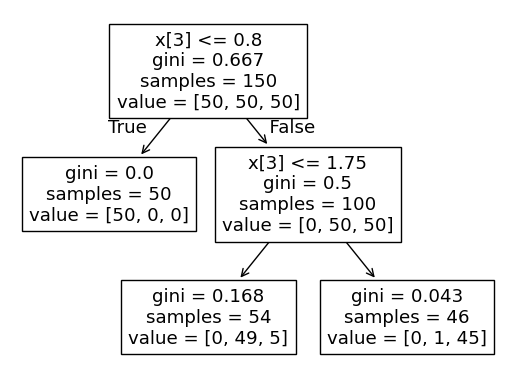

In [38]:

plot_tree(clas)

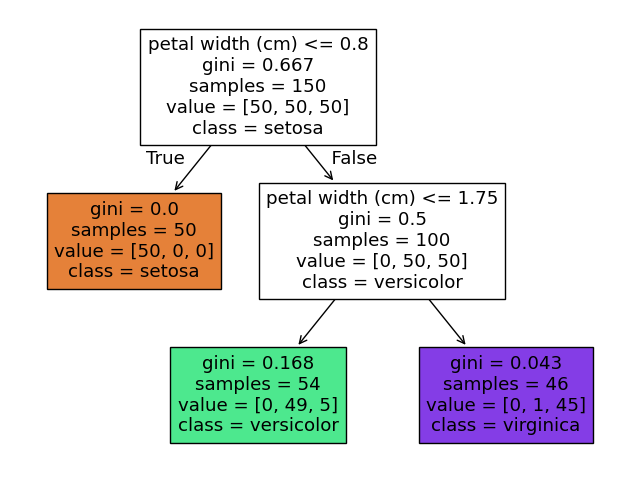

In [6]:
# Quick sanity check with sklearn's built-in (non-dtreeviz) plotting
plt.figure(figsize=(8, 6))
plot_tree(clas, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

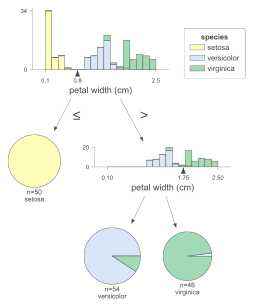

In [8]:
viz = model(
    clas,
    X_train,
    y_train,
    feature_names=iris.feature_names,
    target_name="species",
    class_names=["setosa", "versicolor", "virginica"]
)

# .view() opens an interactive viewer / returns a renderable object.
# In Jupyter, just putting `viz.view()` as the last line of the cell
# will usually render inline via its SVG repr.
viz.view()

# 2. Regression



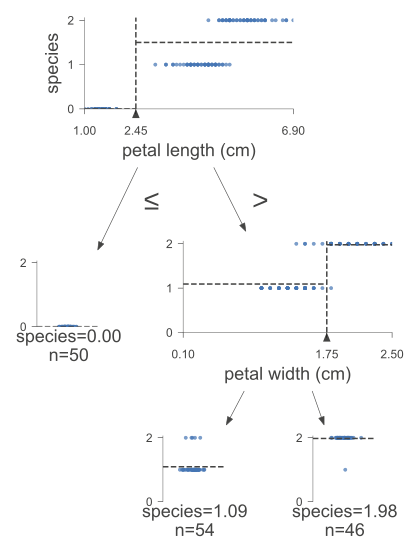

In [62]:
reg = DecisionTreeRegressor(max_depth=2, random_state=42)
X_train=X_train
y_train=y_train
reg.fit(X_train, y_train)

viz = model(
    reg,
    X_train,
    y_train,
    feature_names=iris.feature_names,
    target_name="species",
    class_names=iris.target_names,
    
)

viz.view(scale=2)

# 3. Horizontal Decision Tree

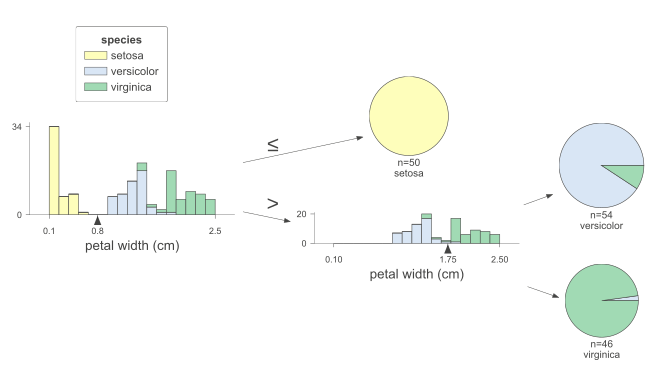

In [13]:
viz = model(
    clas,
    X_train,
    y_train,
    feature_names=iris.feature_names,
    target_name="species",
    class_names=["setosa", "versicolor", "virginica"],
)

viz.view(scale=1.5, orientation="LR")

# 4. Show prediction path

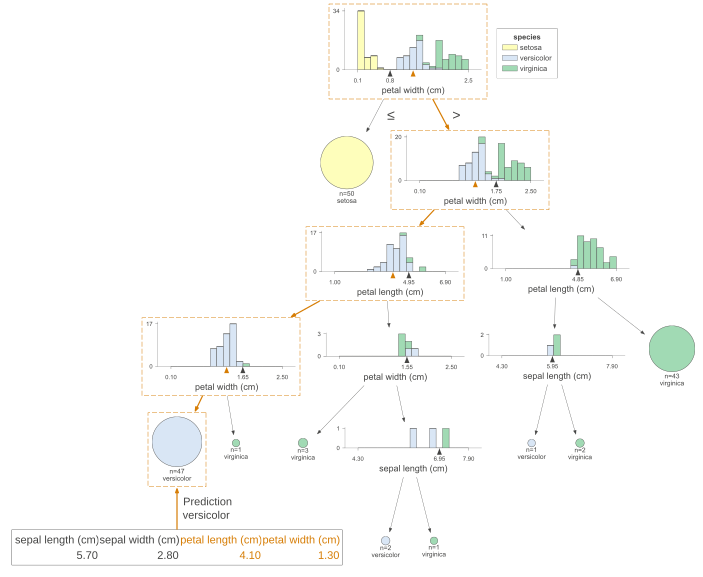

In [66]:
clas = DecisionTreeClassifier()
clas.fit(X_train, y_train)

X = iris.data[np.random.randint(0, len(iris.data)), :]

viz = model(
    clas,
    X_train,
    y_train,
    feature_names=iris.feature_names,
    target_name="species",
    class_names=["setosa", "versicolor", "virginica"],
)

viz.view(x=X)

In [68]:
X

array([5.7, 2.8, 4.1, 1.3])

# 5. Show node number

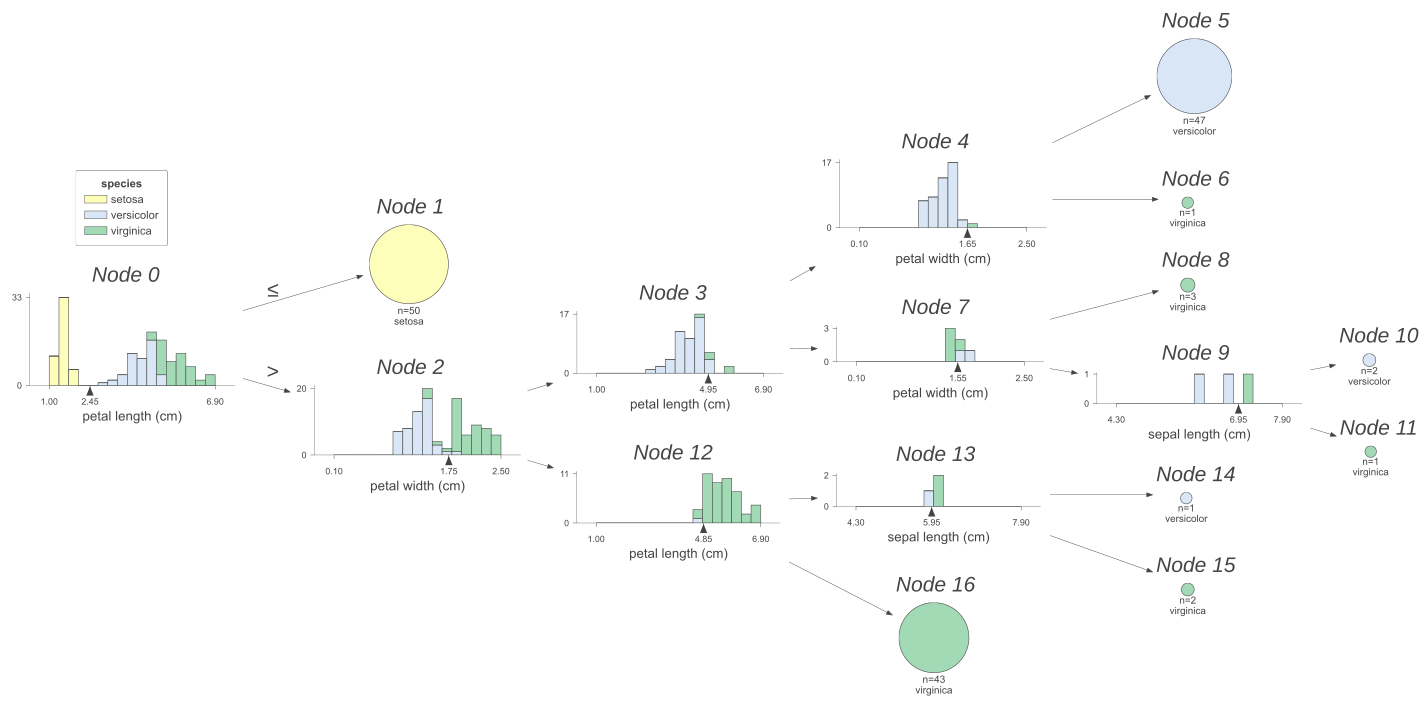

In [18]:
viz = model(
    clas,
    X_train,
    y_train,
    feature_names=iris.feature_names,
    target_name="species",
    class_names=["setosa", "versicolor", "virginica"],
)

viz.view(
    scale=1.5,
    orientation="LR",
    show_node_labels=True,
)

# 6. Without Any graphs

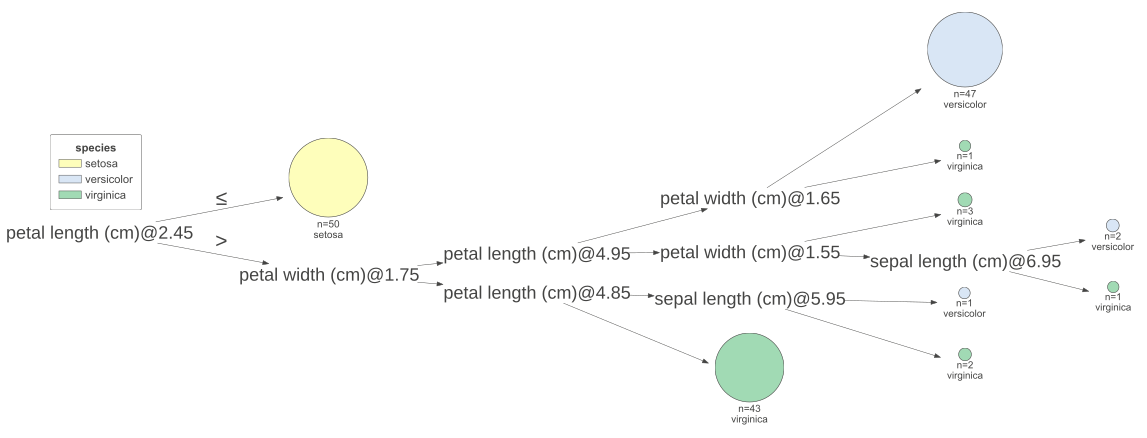

In [20]:
viz.view(
    scale=1.5,
    orientation="LR",
    fancy=False,
)

# 7. Show just prediction path, nothing else

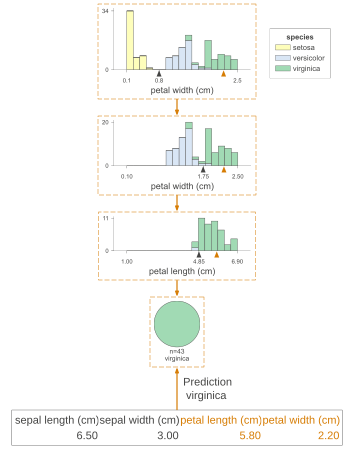

In [22]:
clas = DecisionTreeClassifier()
clas.fit(X_train, y_train)

X = iris.data[np.random.randint(0, len(iris.data)), :]

viz = model(
    clas,
    X_train,
    y_train,
    feature_names=iris.feature_names,
    target_name="species",
    class_names=["setosa", "versicolor", "virginica"],
)

viz.view(x=X, show_just_path=True)

# 8. Prediction Path in Plain English

In [24]:
print(viz.explain_prediction_path(x=X))

4.85 <= petal length (cm) 
1.75 <= petal width (cm) 



# 9. Feature Importance

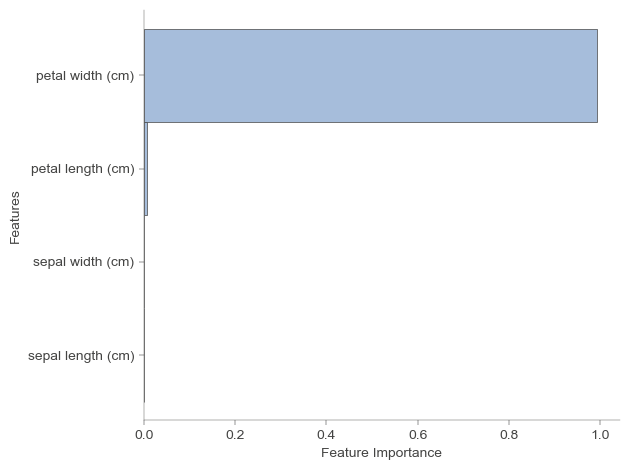

In [26]:
viz.instance_feature_importance(X)

# 10. Univariate Regression

C:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


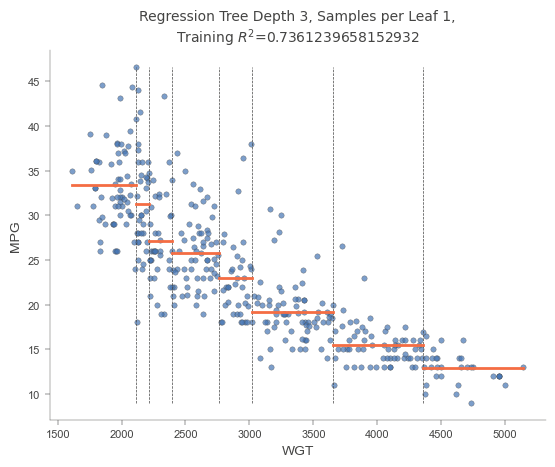

In [28]:

df_cars = pd.read_csv("cars.csv")
X_uni, y_uni = df_cars[["WGT"]], df_cars["MPG"]

dt = DecisionTreeRegressor(max_depth=3)
dt.fit(X_uni, y_uni)

viz = model(
    dt,
    X_train=X_uni,
    y_train=y_uni,
    feature_names=["WGT"],
    target_name="MPG",
)

fig = plt.figure()
ax = fig.gca()
viz.rtree_feature_space(features=["WGT"], ax=ax)
plt.show()

# 11. 3-D Regression

In [30]:
df_cars = pd.read_csv("cars.csv")
df_cars

,MPG,CYL,ENG,WGT
0,18.0,8,307.0,3504
1,15.0,8,350.0,3693
2,18.0,8,318.0,3436
3,16.0,8,304.0,3433
4,17.0,8,302.0,3449
...,...,...,...,...
387,27.0,4,140.0,2790
388,44.0,4,97.0,2130
389,32.0,4,135.0,2295
390,28.0,4,120.0,2625


C:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


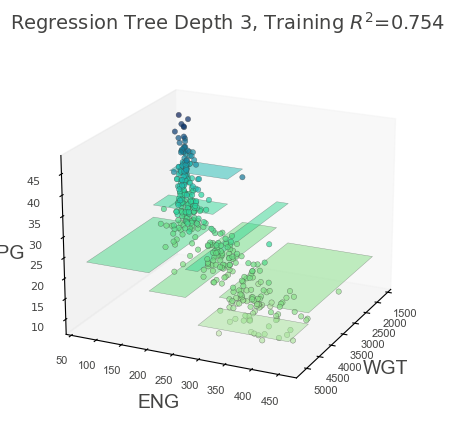

In [32]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

X_biv = df_cars[["WGT", "ENG"]]
y_biv = df_cars["MPG"]

dt = DecisionTreeRegressor(max_depth=3)
dt.fit(X_biv, y_biv)

viz = model(
    dt,
    X_train=X_biv,
    y_train=y_biv,
    feature_names=["WGT", "ENG"],
    target_name="MPG",
)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

viz.rtree_feature_space3D(
    features=["WGT", "ENG"],
    fontsize=14,
    elev=20,
    azim=25,
    show={"splits", "title"},
    ax=ax,
)
plt.show()